# Gradient Descent

**Learning Objectives:**
- Implement gradient descent from scratch with NumPy
- Visualize the effect of learning rate on convergence
- Compare batch GD with sklearn's SGDRegressor
- Understand why feature scaling is critical for gradient-based optimization

**Dataset:** Footfall (bivariate regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

seed = 42

In [2]:
df = pd.read_csv('data/footfall.csv')
df.head()

,x,y
0,4,53
1,5,63
2,9,77
3,10,59
4,12,88


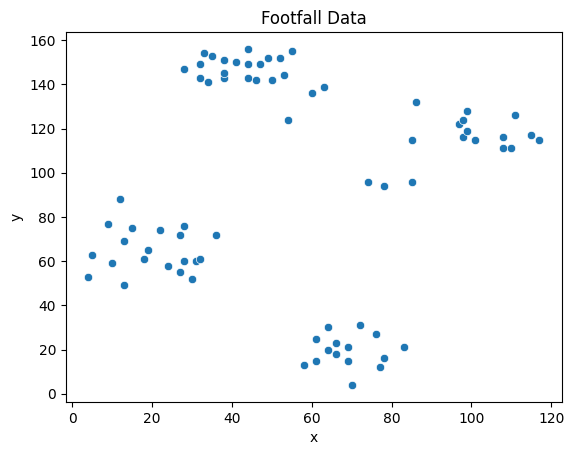

In [3]:
sns.scatterplot(data=df, x='x', y='y')
plt.title('Footfall Data')
plt.show()

### What is Gradient Descent?

Gradient descent minimizes a cost function by iteratively moving parameters in the direction of the negative gradient. For linear regression, we minimize Mean Squared Error (MSE):

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

Parameter update:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

$\alpha$ is the **learning rate** — the step size controlling how far we move each iteration.

### Manual Implementation — Batch Gradient Descent

First we scale features so gradient descent converges smoothly. Without scaling, the elongated cost surface causes divergence even with small learning rates.

In [ ]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradient = (1 / m) * X.T.dot(errors)
        theta = theta - alpha * gradient
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

In [5]:
X = df[['x']].values
y = df['y'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add intercept term (after scaling)
X_train_b = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]
X_test_b = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

print(f'Train: {X_train_b.shape}, Test: {X_test_b.shape}')

Train: (60, 2), Test: (15, 2)


In [6]:
theta_init = np.zeros(2)
alpha = 0.01
iterations = 1000
theta_optimal, cost_history = gradient_descent(
    X_train_b, y_train, theta_init, alpha, iterations
)

print(f'GD coefficients (scaled space): intercept={theta_optimal[0]:.4f}, slope={theta_optimal[1]:.4f}')
print(f'Final cost: {cost_history[-1]:.4f}')

GD coefficients (scaled space): intercept=92.6460, slope=1.9653
Final cost: 2480.2649


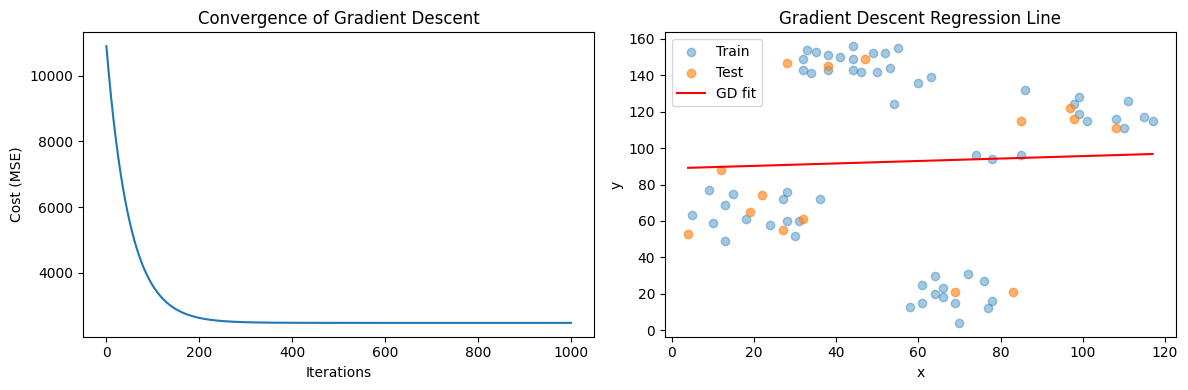

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Convergence of Gradient Descent')

plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, alpha=0.4, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')

# Plot regression line in original space
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
x_line_scaled = scaler.transform(x_line)
x_line_b = np.c_[np.ones((len(x_line_scaled), 1)), x_line_scaled]
y_line = x_line_b.dot(theta_optimal)
plt.plot(x_line, y_line, 'r-', label='GD fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent Regression Line')
plt.legend()

plt.tight_layout()
plt.show()

### Effect of Learning Rate

The learning rate $\alpha$ controls step size:
- **Too small** ($\alpha = 0.001$): slow convergence, many iterations needed
- **Good** ($\alpha = 0.1$): steady convergence to minimum
- **Too large** ($\alpha = 1.0$): diverges — cost increases instead of decreasing

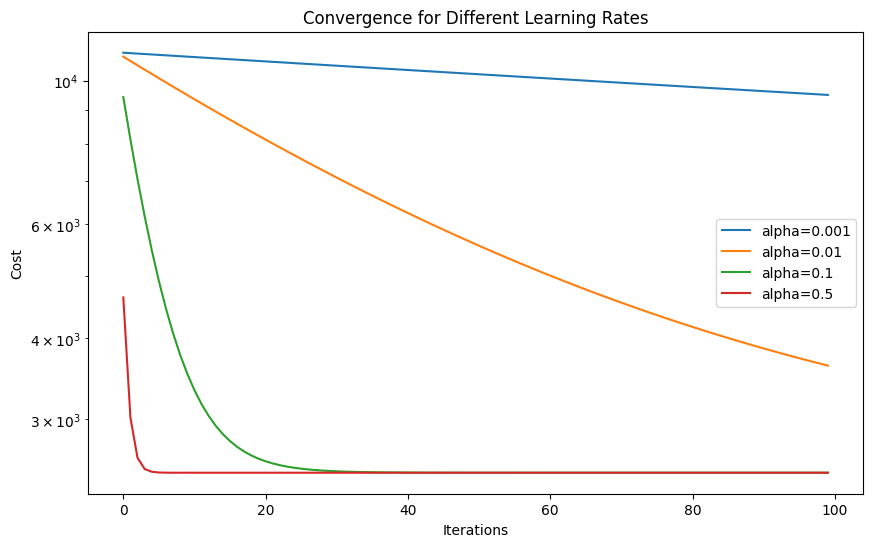

In [8]:
alphas = [0.001, 0.01, 0.1, 0.5]
n_iters = 100

plt.figure(figsize=(10, 6))

for alpha in alphas:
    theta = np.zeros(2)
    _, cost_hist = gradient_descent(X_train_b, y_train, theta, alpha, n_iters)
    plt.plot(range(n_iters), cost_hist, label=f'alpha={alpha}')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Convergence for Different Learning Rates')
plt.legend()
plt.yscale('log')
plt.show()

### Comparison with Closed-Form Solution

The Normal Equation finds optimal $\theta$ in one step: $\theta = (X^T X)^{-1} X^T y$

In [9]:
theta_normal = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
print(f'Normal Eq coefficients (scaled): intercept={theta_normal[0]:.4f}, slope={theta_normal[1]:.4f}')

y_pred_gd = X_test_b.dot(theta_optimal)
y_pred_normal = X_test_b.dot(theta_normal)

print(f'GD R²: {r2_score(y_test, y_pred_gd):.4f}')
print(f'Normal Eq R²: {r2_score(y_test, y_pred_normal):.4f}')

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(f'Sklearn LinearRegression R²: {r2_score(y_test, y_pred_lr):.4f}')

Normal Eq coefficients (scaled): intercept=92.6500, slope=1.9653
GD R²: 0.0104
Normal Eq R²: 0.0104
Sklearn LinearRegression R²: 0.0104


### SGDRegressor — Stochastic Gradient Descent

Sklearn's `SGDRegressor` uses stochastic (per-sample) updates. Unlike batch GD which uses the full dataset per step, SGD updates after each sample — faster for large datasets but noisier convergence.

In [10]:
sgd = SGDRegressor(random_state=seed, max_iter=1000, tol=1e-3)
sgd.fit(X_train_scaled, y_train)
y_pred_sgd = sgd.predict(X_test_scaled)
print(f'SGDRegressor (scaled) R²: {r2_score(y_test, y_pred_sgd):.4f}')

SGDRegressor (scaled) R²: 0.0106


### What Happens Without Scaling?

Gradient descent on unscaled features with mismatched scales leads to a zigzag path or outright divergence. Let's see:

In [11]:
X_train_raw_b = np.c_[np.ones((len(X_train), 1)), X_train]

try:
    theta_raw, cost_raw = gradient_descent(X_train_raw_b, y_train, np.zeros(2), 0.01, 100)
    print(f'Unscaled GD final cost: {cost_raw[-1]:.2f}')
except Exception as e:
    print(f'Unscaled GD diverged: {e}')

Unscaled GD final cost: inf


/tmp/ipykernel_260348/2039506835.py:4: RuntimeWarning: overflow encountered in square
  cost = (1 / (m)) * np.sum((predictions - y) ** 2)


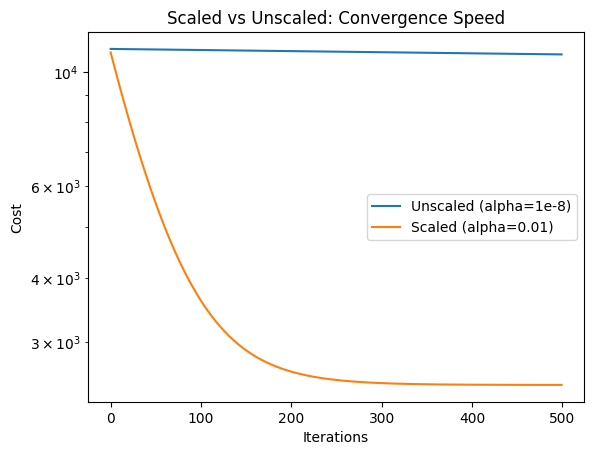

In [12]:
# Even with a tiny learning rate, unscaled converges much slower
theta_raw, cost_raw = gradient_descent(X_train_raw_b, y_train, np.zeros(2), 1e-8, 500)

theta_scaled, cost_scaled = gradient_descent(X_train_b, y_train, np.zeros(2), 0.01, 500)

plt.plot(range(500), cost_raw, label='Unscaled (alpha=1e-8)')
plt.plot(range(500), cost_scaled, label='Scaled (alpha=0.01)')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Scaled vs Unscaled: Convergence Speed')
plt.legend()
plt.yscale('log')
plt.show()

**Key takeaway:** Always scale features before gradient descent. The scaled version converges in ~20 iterations; the unscaled version has barely moved after 500.

### Parameter Notes — SGDRegressor

| Parameter | Default | Description |
|-----------|---------|-------------|
| `loss` | `'squared_error'` | Loss function: squared_error, huber, epsilon_insensitive |
| `penalty` | `'l2'` | Regularization: l1, l2, elasticnet, None |
| `alpha` | 0.0001 | Regularization strength (multiplies penalty) |
| `learning_rate` | `'invscaling'` | Schedule: constant, optimal, invscaling, adaptive |
| `eta0` | 0.01 | Initial learning rate |
| `power_t` | 0.25 | Exponent for inverse scaling schedule |
| `max_iter` | 1000 | Maximum passes (epochs) over training data |
| `tol` | 0.001 | Stopping tolerance. If loss improvement < tol, stop |
| `early_stopping` | False | Stop when validation score stops improving |
| `validation_fraction` | 0.1 | Fraction for early stopping validation |
| `average` | False | Compute averaged SGD weights (better generalization) |

**Tips:**
- Always scale features before SGD — convergence is drastically faster and more stable
- Use `learning_rate='adaptive'` with `eta0` to auto-reduce LR when loss plateaus
- Set `early_stopping=True` to prevent overfitting
- For L1 regularization (sparsity), use `penalty='l1'`

## Exercises

1. Try `alpha=1.0` in the manual GD. What happens to the cost history? Why?
2. Use `SGDRegressor(learning_rate='adaptive', eta0=0.1)` and compare the R² score.
3. Apply gradient descent (with scaling) to the `salary_dataset.csv` dataset. Compare coefficients with `LinearRegression`.
4. Use `SGDClassifier` on the diabetes dataset (binary classification). Scale features and compare accuracy with `LogisticRegression`.

In [13]:
# TODO: Complete the exercises